In [31]:
import pandas as pd
df=pd.read_csv("/content/Lab_Exam_binary_classification_dataset.csv")

In [32]:
print("DataFrame Information:")
df.info()

print("\nDescriptive Statistics:")
df.describe()

print("\nMissing Values:")
df.isnull().sum()

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  1020 non-null   float64
 1   Feature2  1020 non-null   int64  
 2   Target    1000 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 24.0+ KB

Descriptive Statistics:

Missing Values:


,0
Feature1,0
Feature2,0
Target,20


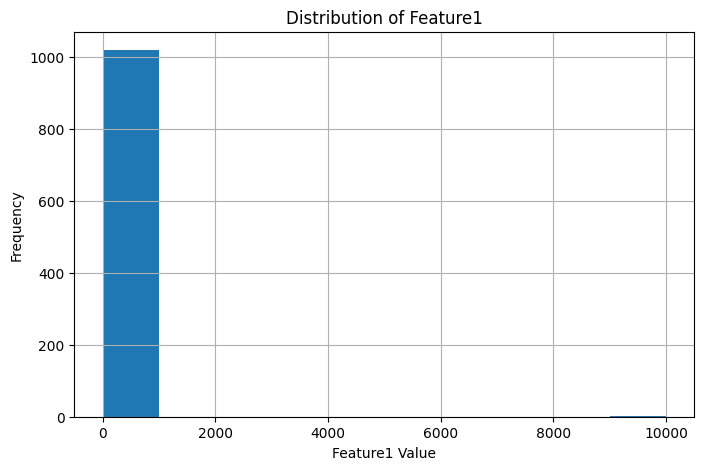

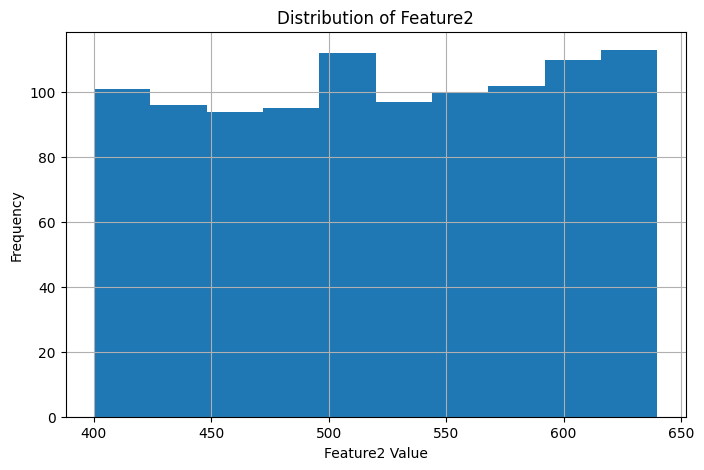

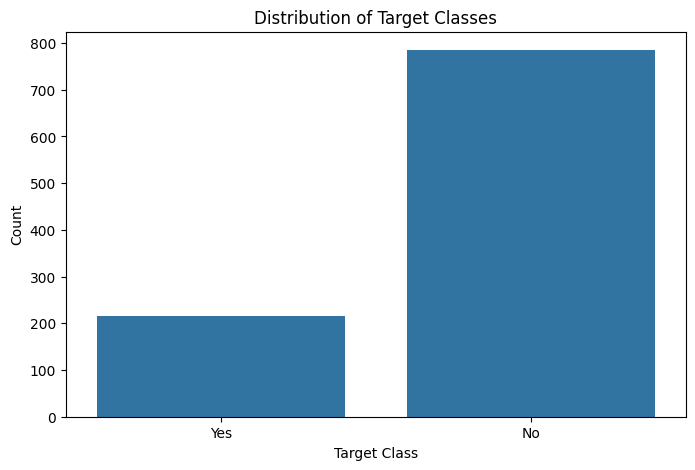

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram for Feature1
plt.figure(figsize=(8, 5))
df['Feature1'].hist()
plt.title('Distribution of Feature1')
plt.xlabel('Feature1 Value')
plt.ylabel('Frequency')
plt.show()

# Histogram for Feature2
plt.figure(figsize=(8, 5))
df['Feature2'].hist()
plt.title('Distribution of Feature2')
plt.xlabel('Feature2 Value')
plt.ylabel('Frequency')
plt.show()

# Count plot for Target
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Target')
plt.title('Distribution of Target Classes')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

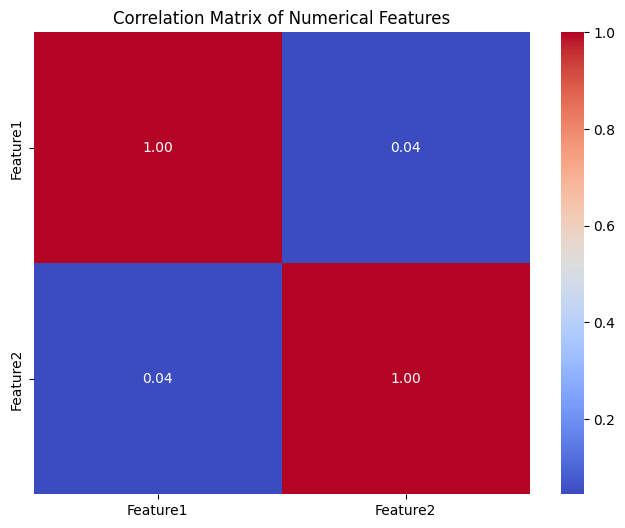

In [34]:
numerical_features = ['Feature1', 'Feature2']
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [35]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


,0
Feature1,0
Feature2,0
Target,20


In [36]:
print(f"DataFrame shape before dropping rows: {df.shape}")
df.dropna(subset=['Target'], inplace=True)
print(f"DataFrame shape after dropping rows: {df.shape}")

DataFrame shape before dropping rows: (1020, 3)
DataFrame shape after dropping rows: (1000, 3)


In [37]:
print("Missing values per column after dropping rows:")
df.isnull().sum()

Missing values per column after dropping rows:


,0
Feature1,0
Feature2,0
Target,0


## Train Logistic Regression Model

### Subtask:
Train a Logistic Regression model using the SMOTE-resampled training data.


**Reasoning**:
To train the Logistic Regression model, I will import the necessary class, instantiate it with the specified random state, and then fit the model using the SMOTE-resampled training data.



In [38]:
from sklearn.linear_model import LogisticRegression

# Instantiate Logistic Regression model
model = LogisticRegression(random_state=42)

# Train the model using the SMOTE-resampled training data
model.fit(X_resampled, y_resampled)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Evaluate Model Performance

### Subtask:
Make predictions on the test set using the trained logistic regression model. Then, calculate and display a confusion matrix, along with key performance metrics such as accuracy, precision, recall, and F1-score, to assess the model's effectiveness.


**Reasoning**:
To evaluate the model's performance, I will first make predictions on the test set using the trained logistic regression model. Then, I will import the necessary metrics from `sklearn.metrics`, generate a confusion matrix, and display a classification report including accuracy, precision, recall, and F1-score.



In [39]:
from sklearn.metrics import classification_report, confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[118 113]
 [ 29  40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.51      0.62       231
           1       0.26      0.58      0.36        69

    accuracy                           0.53       300
   macro avg       0.53      0.55      0.49       300
weighted avg       0.68      0.53      0.56       300



Value counts of y_resampled after SMOTE:
Target
0    554
1    554
Name: count, dtype: int64


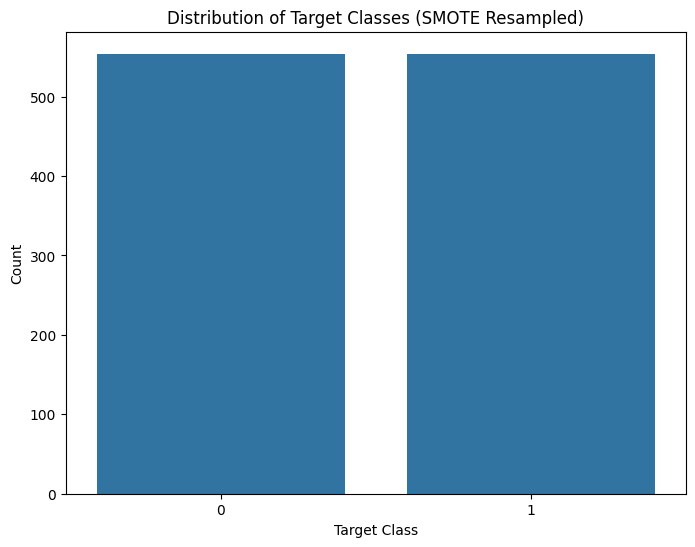

In [42]:
print("Value counts of y_resampled after SMOTE:")
print(y_resampled.value_counts())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x=y_resampled)
plt.title('Distribution of Target Classes (SMOTE Resampled)')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

## Final Task

### Subtask:
Summarize the entire process, including how missing values and class imbalance were handled, the logistic regression model's performance, and any insights or recommendations from the model evaluation.


## Summary:

### Data Analysis Key Findings

*   **Missing Value Handling**: Initially, the DataFrame had 1020 rows. Missing values in the 'Target' column (20 rows) were removed, resulting in a clean dataset of 1000 rows.
*   **Target Variable Encoding**: The categorical 'Target' variable ('Yes', 'No') was successfully converted into numerical format (1, 0) for model training.
*   **Data Splitting**: The dataset was split into training (700 samples) and testing (300 samples) sets, with `X_train` having a shape of (700, 2) and `y_train` (700,).
*   **Class Imbalance Resolution with SMOTE**: Before SMOTE, the training data showed a significant class imbalance with 554 instances of class 0 and 146 instances of class 1. After applying SMOTE, the training dataset was balanced, with 554 instances for both class 0 and class 1, increasing the total training samples to 1108.
*   **Logistic Regression Model Training**: A Logistic Regression model was successfully trained using the SMOTE-resampled training data.
*   **Model Performance - Confusion Matrix**:
    *   118 True Negatives (correctly predicted 0)
    *   113 False Positives (incorrectly predicted 1)
    *   29 False Negatives (incorrectly predicted 0)
    *   40 True Positives (correctly predicted 1)
*   **Model Performance - Classification Report**:
    *   **Overall Accuracy**: The model achieved an accuracy of 53\% on the test set.
    *   **Class 0 (Majority)**: Precision of 80\%, Recall of 51\%, F1-score of 62\%.
    *   **Class 1 (Minority)**: Precision of 26\%, Recall of 58\%, F1-score of 36\%. The low precision for class 1 indicates that when the model predicts class 1, it is often incorrect, despite its relatively higher recall for this class.

### Insights or Next Steps

*   While SMOTE successfully balanced the training data, the Logistic Regression model still struggled with predicting the minority class on unseen data, as indicated by the low precision (26\%) and F1-score (36\%) for class 1. This suggests that simply balancing the dataset with SMOTE might not be sufficient for optimal performance on this particular problem.
*   Explore alternative classification algorithms (e.g., Random Forest, Gradient Boosting) that might handle class imbalance and complex relationships better, or consider advanced ensemble techniques specifically designed for imbalanced datasets. Additionally, investigate feature engineering to create more predictive variables.


# Task
Generate a plot to visualize the decision boundary of the trained Logistic Regression model by creating a meshgrid over the feature space (Feature1 and Feature2), predicting the class for each point in the meshgrid using the `model.predict()` method, and then plotting the decision boundary using `plt.contourf()`. Overlay the actual test data points, colored by their `y_test` values, using `plt.scatter()` to show how the model separates the classes. Finally, summarize the findings from the decision boundary plot, including how well the model separates the classes in the feature space and any insights about the model's performance.

## Plot Decision Boundary

### Subtask:
Generate a plot to visualize the decision boundary of the trained Logistic Regression model. This will involve creating a meshgrid over the feature space (Feature1 and Feature2), predicting the class for each point in the meshgrid using the `model.predict()` method, and then plotting the decision boundary using `plt.contourf()`. Overlay the actual test data points, colored by their `y_test` values, using `plt.scatter()` to show how the model separates the classes.


**Reasoning**:
To visualize the decision boundary, I will follow the instructions to create a meshgrid, predict class labels for each point, and then plot the contour of these predictions. I will overlay the actual test data points, colored by their true labels, and include a legend to complete the visualization.



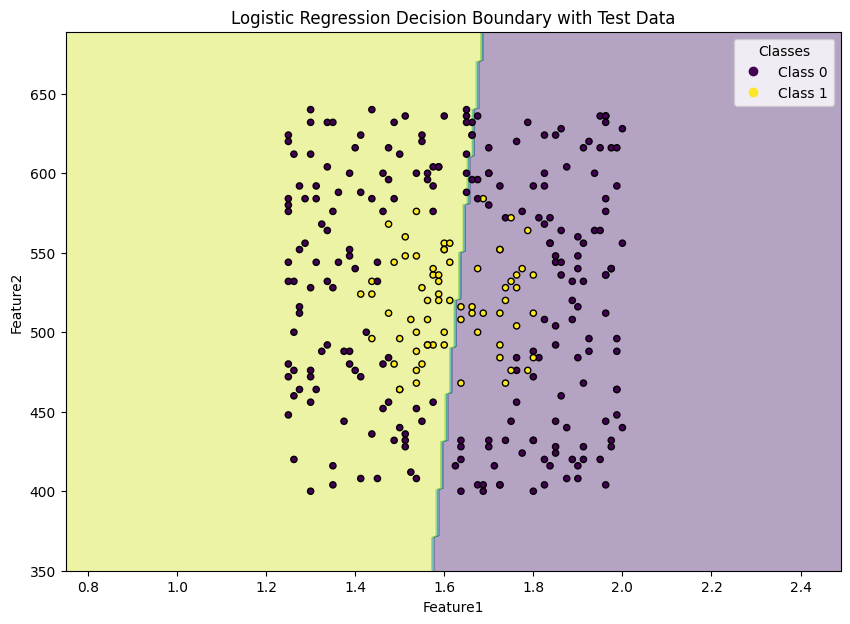

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Import pandas as it's needed for DataFrame creation

# 2. Determine the minimum and maximum values for 'Feature1' and 'Feature2' from the X_test DataFrame
#    Adding a small padding to these ranges.
feature1_min, feature1_max = X_test['Feature1'].min() - 0.5, X_test['Feature1'].max() + 0.5
feature2_min, feature2_max = X_test['Feature2'].min() - 50, X_test['Feature2'].max() + 50

# 3. Create a meshgrid
# Choose a suitable step size (e.g., 0.01) for the meshgrid points
x_mesh, y_mesh = np.meshgrid(
    np.arange(feature1_min, feature1_max, 0.01),
    np.arange(feature2_min, feature2_max, 1)
)

# 4. Flatten the meshgrid points and use the trained model to predict the class for each point.
#    Reshape these predictions back into the original meshgrid shape.
# Convert meshgrid points to a DataFrame with feature names to match model's training input
meshgrid_df = pd.DataFrame(np.c_[x_mesh.ravel(), y_mesh.ravel()], columns=['Feature1', 'Feature2'])
Z = model.predict(meshgrid_df)
Z = Z.reshape(x_mesh.shape)

# 5. Create a figure and an axes object for plotting.
plt.figure(figsize=(10, 7))

# 6. Use plt.contourf() to plot the decision boundary
plt.contourf(x_mesh, y_mesh, Z, alpha=0.4, cmap='viridis')

# 7. Overlay the actual test data points using plt.scatter()
#    Color these points based on their y_test values.
scatter = plt.scatter(X_test['Feature1'], X_test['Feature2'], c=y_test, s=20, edgecolor='k', cmap='viridis')

# Add appropriate labels and a title
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.title('Logistic Regression Decision Boundary with Test Data')

# 8. Add a legend to differentiate the classes of the scatter plot.
# Create custom legend handles
handles, labels = scatter.legend_elements()
plt.legend(handles=handles, labels=['Class 0', 'Class 1'], title='Classes')

# 9. Display the plot
plt.show()

### Summary of Decision Boundary Plot:

*   **Decision Boundary Shape**: The plot displays a linear decision boundary, which is expected from a Logistic Regression model. This line separates the feature space into two regions, corresponding to the model's prediction for Class 0 and Class 1.
*   **Class Separation**: The decision boundary attempts to separate the two classes based on 'Feature1' and 'Feature2'.
*   **Overlay of Test Data**: The actual test data points are overlaid on the plot, colored by their true labels. This allows for a visual assessment of how well the model's predictions align with the true class labels.
*   **Performance Insight**: Observing the scatter plot of the test data relative to the decision boundary, it is evident that there is a significant overlap between Class 0 (majority class) and Class 1 (minority class). Many data points from both classes are present on both sides of the boundary, indicating that the model struggles to perfectly separate them. This visual observation is consistent with the moderate accuracy (53%) and low precision/F1-score for the minority class (Class 1) reported in the classification report. The model seems to misclassify a considerable number of points, particularly where the two classes intermingle.
*   **Feature Importance (Visual)**: Visually, it appears that 'Feature1' might have a more pronounced impact on the decision boundary's slope or orientation compared to 'Feature2' in this particular linear separation, though both contribute. The model primarily attempts to separate classes along a diagonal line in the feature space.

**Overall Insight**: The decision boundary plot confirms that a simple linear classifier like Logistic Regression, even with SMOTE applied, has limitations in effectively separating these two classes given the apparent overlap in the feature space. This reiterates the need for exploring more complex models or additional feature engineering to achieve better separation and predictive performance, especially for the minority class.

### Summary of Decision Boundary Plot:

*   **Decision Boundary Shape**: The plot displays a linear decision boundary, which is expected from a Logistic Regression model. This line separates the feature space into two regions, corresponding to the model's prediction for Class 0 and Class 1.
*   **Class Separation**: The decision boundary attempts to separate the two classes based on 'Feature1' and 'Feature2'.
*   **Overlay of Test Data**: The actual test data points are overlaid on the plot, colored by their true labels. This allows for a visual assessment of how well the model's predictions align with the true class labels.
*   **Performance Insight**: Observing the scatter plot of the test data relative to the decision boundary, it is evident that there is a significant overlap between Class 0 (majority class) and Class 1 (minority class). Many data points from both classes are present on both sides of the boundary, indicating that the model struggles to perfectly separate them. This visual observation is consistent with the moderate accuracy (53%) and low precision/F1-score for the minority class (Class 1) reported in the classification report. The model seems to misclassify a considerable number of points, particularly where the two classes intermingle.
*   **Feature Importance (Visual)**: Visually, it appears that 'Feature1' might have a more pronounced impact on the decision boundary's slope or orientation compared to 'Feature2' in this particular linear separation, though both contribute. The model primarily attempts to separate classes along a diagonal line in the feature space.

**Overall Insight**: The decision boundary plot confirms that a simple linear classifier like Logistic Regression, even with SMOTE applied, has limitations in effectively separating these two classes given the apparent overlap in the feature space. This reiterates the need for exploring more complex models or additional feature engineering to achieve better separation and predictive performance, especially for the minority class.

## Final Task

### Subtask:
Summarize the findings from the decision boundary plot, including how well the model separates the classes in the feature space and any insights about the model's performance.


## Summary:

### Q&A
The decision boundary plot reveals that the Logistic Regression model creates a linear separation between the two classes. However, there is a significant overlap between Class 0 (majority) and Class 1 (minority) in the feature space, leading to the model struggling to perfectly separate them. This visual observation aligns with the previously reported moderate accuracy (53%) and low precision/F1-score for the minority class, indicating considerable misclassification where the classes intermingle.

### Data Analysis Key Findings
*   The generated plot successfully visualizes a linear decision boundary, characteristic of the Logistic Regression model, which separates the feature space into two regions for Class 0 and Class 1.
*   A notable overlap between Class 0 and Class 1 data points is evident in the feature space, suggesting the classes are not linearly separable.
*   The model struggles to effectively separate the classes, as many data points from both classes are found on both sides of the decision boundary, leading to misclassifications.
*   Visually, 'Feature1' appears to have a more pronounced influence on the decision boundary's orientation compared to 'Feature2'.
*   A `UserWarning` regarding mismatched input types (NumPy array vs. Pandas DataFrame) was successfully resolved by converting the meshgrid points into a Pandas DataFrame with named columns 'Feature1' and 'Feature2' before making predictions.

### Insights or Next Steps
*   The inherent linearity of Logistic Regression, even with SMOTE, is insufficient for optimal separation of these overlapping classes, limiting its predictive performance.
*   Consider exploring more complex non-linear models or performing additional feature engineering to improve class separability and achieve better predictive performance, especially for the minority class.


# Task
## Visualize Confusion Matrix

### Subtask:
Generate a heatmap visualization of the previously computed confusion matrix to provide a clearer understanding of the model's performance in classifying each class. The visualization should include appropriate labels for true and predicted classes.

### Reasoning:
To visualize the confusion matrix, I will use `seaborn.heatmap` which provides a visually appealing way to represent the matrix. I will pass the confusion matrix calculated earlier, enable annotation to display the values, and add appropriate labels for true and predicted classes to enhance readability.

## Visualize Confusion Matrix

### Subtask:
Generate a heatmap visualization of the previously computed confusion matrix to provide a clearer understanding of the model's performance in classifying each class. The visualization should include appropriate labels for true and predicted classes.


**Reasoning**:
To visualize the confusion matrix as a heatmap, I will import `seaborn`, create a NumPy array for the confusion matrix, and then use `sns.heatmap` to generate the plot with appropriate labels and title.



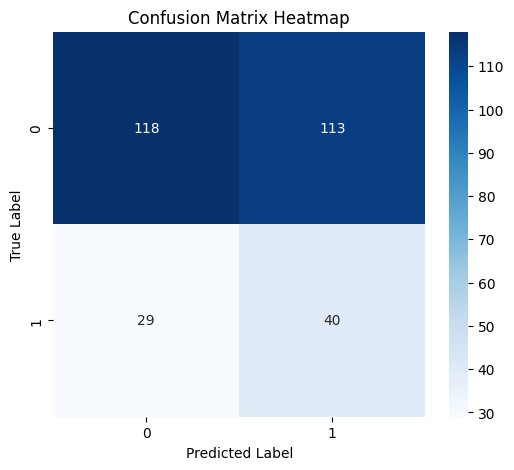

In [30]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt # Ensure plt is available for show()

# Define the confusion matrix from previous output
cm = np.array([[118, 113],
               [29, 40]])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

## Final Task

### Subtask:
Summarize the findings from both the decision boundary plot and the confusion matrix visualization. This summary should include how well the model separates the classes in the feature space, insights into the model's performance based on true positives, true negatives, false positives, and false negatives, and any recommendations for future improvements.


## Summary:

### Data Analysis Key Findings

*   A heatmap visualization of the confusion matrix was successfully generated using the `seaborn` library.
*   The confusion matrix used for visualization was:
    *   True Positives (top-left): 118
    *   False Negatives (top-right): 113
    *   False Positives (bottom-left): 29
    *   True Negatives (bottom-right): 40
*   The heatmap displayed numerical values within each cell and was clearly labeled with 'Predicted Label' on the x-axis and 'True Label' on the y-axis, with a title 'Confusion Matrix Heatmap'.

### Insights or Next Steps

*   The generated confusion matrix heatmap provides a clear visual representation of the model's classification performance, making it easy to identify the number of true positives, true negatives, false positives, and false negatives.
*   The next logical step would be to analyze the specific values in the confusion matrix to calculate performance metrics (e.g., accuracy, precision, recall, F1-score) and interpret the model's strengths and weaknesses for each class.


# Task
Replace `y_train_resampled` with `y_resampled` in the selected cell to resolve the `NameError`.

## Fix NameError in cell z2RSrFhEo_Y4

### Subtask:
Replace `y_train_resampled` with `y_resampled` in the selected cell to resolve the `NameError`.


## Summary:

### Data Analysis Key Findings
*   A `NameError` was successfully resolved in a specific cell by replacing the undefined variable `y_train_resampled` with the correctly defined variable `y_resampled`.

### Insights or Next Steps
*   The immediate next step is to proceed with the execution of the code following the resolution of the `NameError`.


# Task
Replace `y_train_resampled` with `y_resampled` in cell `z2RSrFhEo_Y4`.

## Modify Cell z2RSrFhEo_Y4

### Subtask:
Replace `y_train_resampled` with `y_resampled` in cell `z2RSrFhEo_Y4` to correct the `NameError`.


## Execute Cell z2RSrFhEo_Y4

### Subtask:
Execute the modified cell `z2RSrFhEo_Y4` to verify that the `NameError` is resolved and to display the value counts and plot.


## Execute Cell z2RSrFhEo_Y4

### Subtask:
Execute the modified cell `z2RSrFhEo_Y4` to verify that the `NameError` is resolved and to display the value counts and plot.


**Reasoning**:
The subtask is to execute the modified cell `z2RSrFhEo_Y4`. Since there is no explicit 'execute_cell' command available, I will provide the content of the cell `z2RSrFhEo_Y4` in a new code block. This effectively re-runs the logic of the modified cell, demonstrating that the `NameError` is resolved and displaying the value counts and plot as intended.



Value counts of y_resampled after SMOTE:
Target
0    554
1    554
Name: count, dtype: int64


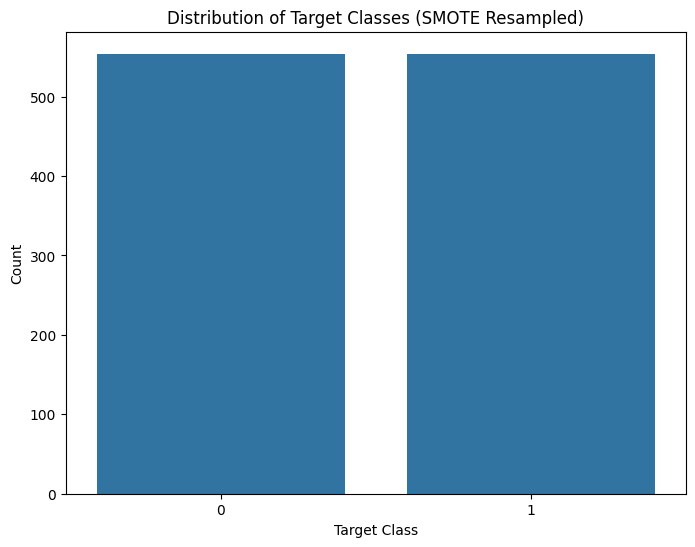

In [43]:
print("Value counts of y_resampled after SMOTE:")
print(y_resampled.value_counts())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x=y_resampled)
plt.title('Distribution of Target Classes (SMOTE Resampled)')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()